In [ ]:
test_inputs = [
    "I'm feeling really stressed about my upcoming exams.",
    "I lost my job today and I don't know what to do.",
    "My best friend just got married and I feel so happy for them!",
    "I can't stop thinking about what happened last year. I feel so ashamed.",
    "I'm scared about my health results coming back tomorrow."
]

print("=" * 60)
for user_input in test_inputs:
    emotion, reply = generate_empathetic_response(user_input)
    print(f"User       : {user_input}")
    print(f"Emotion    : {emotion}")
    print(f"Therapist  : {reply}")
    print("-" * 60)

AttributeError: 

# Emotional Therapist AI — v2
**Changes from v1:**
- DistilBERT emotion classifier: `num_train_epochs` reduced from **8 → 4**
- Response generator: **DialoGPT replaced with Qwen2.5-1.5B-Instruct**
- Inference pipeline updated to use Qwen's chat-template format

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 0. Install dependencies

In [2]:
!pip install transformers datasets torch scikit-learn accelerate -q

## 1. Load & Explore Data

In [3]:
import pandas as pd
import torch

path = r'/content/emotion-emotion_69k.csv'
df = pd.read_csv(path, on_bad_lines='skip', engine='python')
df.head()

,Unnamed: 0,Situation,emotion,empathetic_dialogues,labels,Unnamed: 5,Unnamed: 6
0,0,I remember going to the fireworks with my best...,sentimental,Customer :I remember going to see the firework...,"Was this a friend you were in love with, or ju...",NaN,NaN
1,1,I remember going to the fireworks with my best...,sentimental,Customer :This was a best friend. I miss her.\...,Where has she gone?,NaN,NaN
2,2,I remember going to the fireworks with my best...,sentimental,Customer :We no longer talk.\nAgent :,Oh was this something that happened because of...,NaN,NaN
3,3,I remember going to the fireworks with my best...,sentimental,Customer :Was this a friend you were in love w...,This was a best friend. I miss her.,NaN,NaN
4,4,I remember going to the fireworks with my best...,sentimental,Customer :Where has she gone?\nAgent :,We no longer talk.,NaN,NaN


In [4]:
df.shape

(64636, 7)

## 2. Data Cleaning

In [5]:
# Drop junk columns
df.drop(['Unnamed: 0'], axis=1, inplace=True)
df.drop(['Unnamed: 5', 'Unnamed: 6'], axis=1, inplace=True)
df.head()

,Situation,emotion,empathetic_dialogues,labels
0,I remember going to the fireworks with my best...,sentimental,Customer :I remember going to see the firework...,"Was this a friend you were in love with, or ju..."
1,I remember going to the fireworks with my best...,sentimental,Customer :This was a best friend. I miss her.\...,Where has she gone?
2,I remember going to the fireworks with my best...,sentimental,Customer :We no longer talk.\nAgent :,Oh was this something that happened because of...
3,I remember going to the fireworks with my best...,sentimental,Customer :Was this a friend you were in love w...,This was a best friend. I miss her.
4,I remember going to the fireworks with my best...,sentimental,Customer :Where has she gone?\nAgent :,We no longer talk.


In [6]:
# Check nulls
df.isna().sum()

,0
Situation,0
emotion,4
empathetic_dialogues,0
labels,0


In [7]:
# Drop rows with no emotion label
df.dropna(subset=['emotion'], inplace=True)
df.isna().sum()

,0
Situation,0
emotion,0
empathetic_dialogues,0
labels,0


In [8]:
df.shape

(64632, 4)

## 3. EDA — Text Length & Emotion Distribution

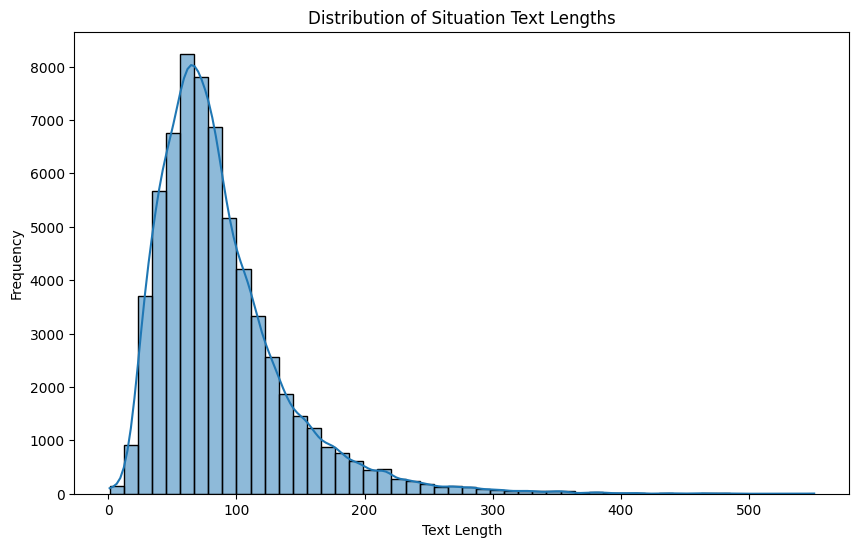

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

df['situation_length'] = df['Situation'].apply(lambda x: len(str(x)))

plt.figure(figsize=(10, 6))
sns.histplot(df['situation_length'], bins=50, kde=True)
plt.title('Distribution of Situation Text Lengths')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()

/tmp/ipykernel_1404/1698065805.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette='viridis')
/tmp/ipykernel_1404/1698065805.py:9: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


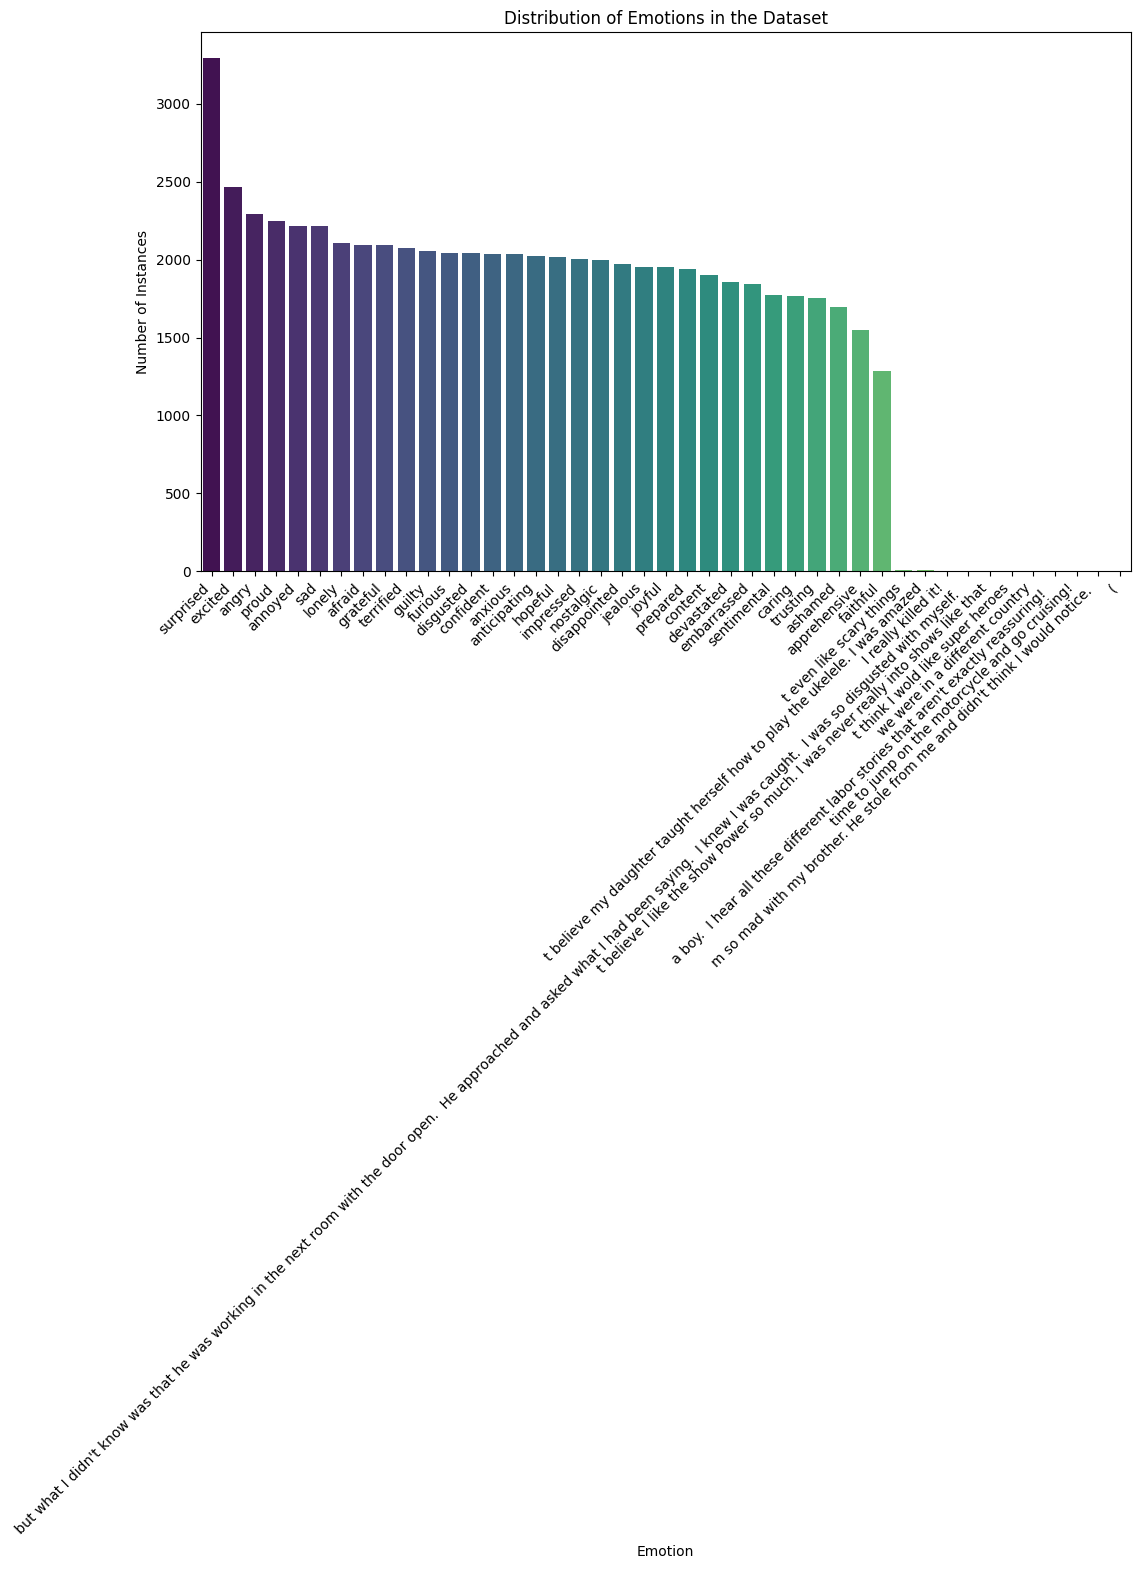

In [10]:
emotion_counts = df['emotion'].value_counts()

plt.figure(figsize=(12, 7))
sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette='viridis')
plt.title('Distribution of Emotions in the Dataset')
plt.xlabel('Emotion')
plt.ylabel('Number of Instances')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Text Pre-processing

In [11]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['Situation']             = df['Situation'].astype(str).apply(clean_text)
df['empathetic_dialogues']  = df['empathetic_dialogues'].astype(str).apply(clean_text)
df['labels']                = df['labels'].astype(str).apply(clean_text)
df['emotion']               = df['emotion'].astype(str).apply(clean_text)

print("Rows with special chars:",
      df['Situation'].str.contains(r'[^a-zA-Z\s]', regex=True).sum())
print("Rows with uppercase:",
      df['Situation'].str.contains(r'[A-Z]', regex=True).sum())

Rows with special chars: 0
Rows with uppercase: 0


## 5. Filter Emotions & Train/Val/Test Split

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

valid_emotions = [
    'sentimental', 'afraid', 'proud', 'faithful', 'terrified', 'joyful',
    'angry', 'sad', 'jealous', 'grateful', 'prepared', 'embarrassed',
    'excited', 'annoyed', 'lonely', 'ashamed', 'guilty', 'surprised',
    'disgusted', 'anticipating', 'hopeful', 'confident', 'furious',
    'anxious', 'nostalgic', 'devastated', 'apprehensive', 'impressed',
    'caring', 'trusting', 'content'
]
df = df[df['emotion'].isin(valid_emotions)]

# Combine input for richer context
df['combined_input'] = (
    df['Situation'].fillna('') + " [SEP] " +
    df['empathetic_dialogues'].fillna('')
)

X = df['combined_input']
y = df['emotion']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train: {len(X_train)}  |  Val: {len(X_val)}  |  Test: {len(X_test)}")

Train: 43835  |  Val: 9393  |  Test: 9394


## 6. Baseline — SVM Classifier

In [13]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

vectorizer = TfidfVectorizer(
    max_features=20000, ngram_range=(1, 2),
    sublinear_tf=True, stop_words='english'
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

svm_model = LinearSVC(class_weight='balanced')
svm_model.fit(X_train_tfidf, y_train)
svm_pred = svm_model.predict(X_test_tfidf)

svm_accuracy  = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred, average='weighted')
svm_recall    = recall_score(y_test, svm_pred, average='weighted')
svm_f1        = f1_score(y_test, svm_pred, average='weighted')

print(f"SVM  Accuracy : {svm_accuracy:.4f}")
print(f"SVM  Precision: {svm_precision:.4f}")
print(f"SVM  Recall   : {svm_recall:.4f}")
print(f"SVM  F1-score : {svm_f1:.4f}")

SVM  Accuracy : 0.8355
SVM  Precision: 0.8354
SVM  Recall   : 0.8355
SVM  F1-score : 0.8350


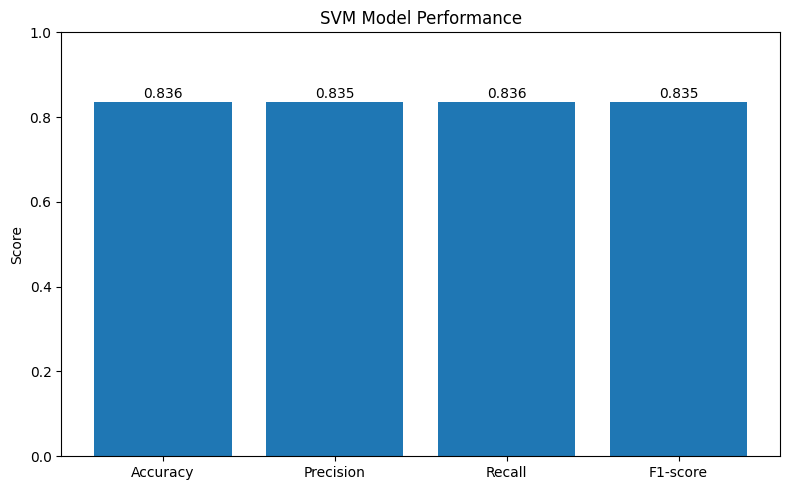

In [14]:
# Bar chart – SVM
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
values  = [svm_accuracy, svm_precision, svm_recall, svm_f1]

plt.figure(figsize=(8, 5))
plt.bar(metrics, values)
plt.ylabel('Score')
plt.ylim(0, 1)
plt.title('SVM Model Performance')
for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')
plt.tight_layout()
plt.show()

## 7. Baseline — Logistic Regression Classifier

In [15]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=200, solver='saga', class_weight='balanced'
)
lr_model.fit(X_train_tfidf, y_train)
lr_pred = lr_model.predict(X_test_tfidf)

lr_accuracy  = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred, average='weighted')
lr_recall    = recall_score(y_test, lr_pred, average='weighted')
lr_f1        = f1_score(y_test, lr_pred, average='weighted')

print(f"LR  Accuracy : {lr_accuracy:.4f}")
print(f"LR  Precision: {lr_precision:.4f}")
print(f"LR  Recall   : {lr_recall:.4f}")
print(f"LR  F1-score : {lr_f1:.4f}")

LR  Accuracy : 0.6743
LR  Precision: 0.6734
LR  Recall   : 0.6743
LR  F1-score : 0.6722


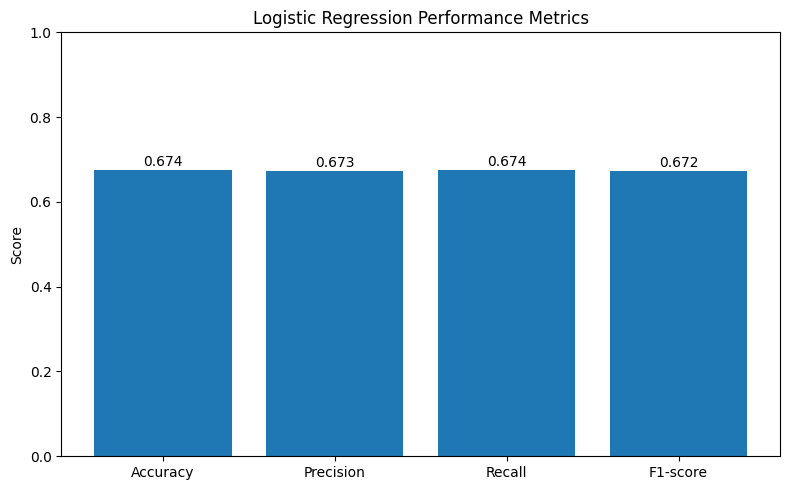

In [16]:
# Bar chart – Logistic Regression
values_lr = [lr_accuracy, lr_precision, lr_recall, lr_f1]

plt.figure(figsize=(8, 5))
plt.bar(metrics, values_lr)
plt.ylabel('Score')
plt.ylim(0, 1)
plt.title('Logistic Regression Performance Metrics')
for i, v in enumerate(values_lr):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')
plt.tight_layout()
plt.show()

## 8. Confusion-Matrix Utility

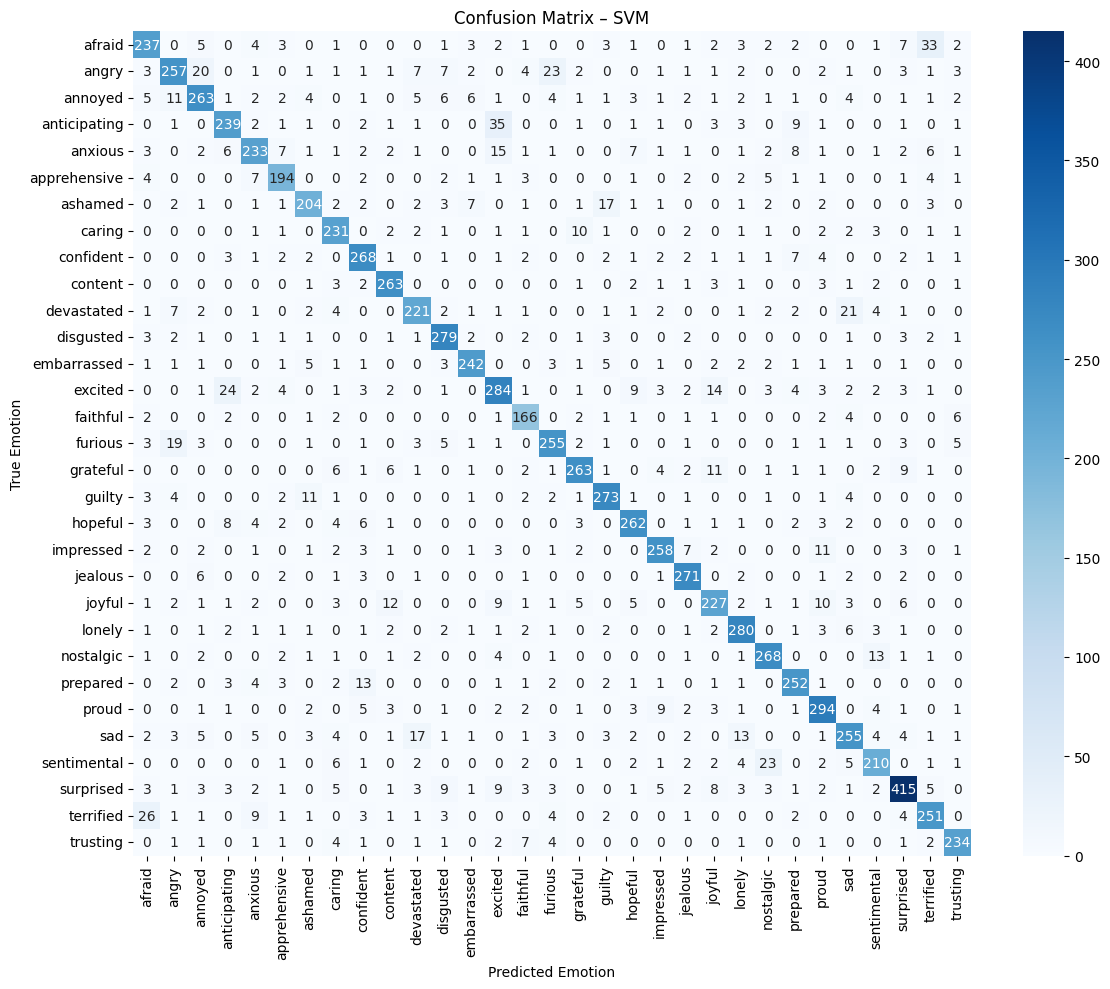

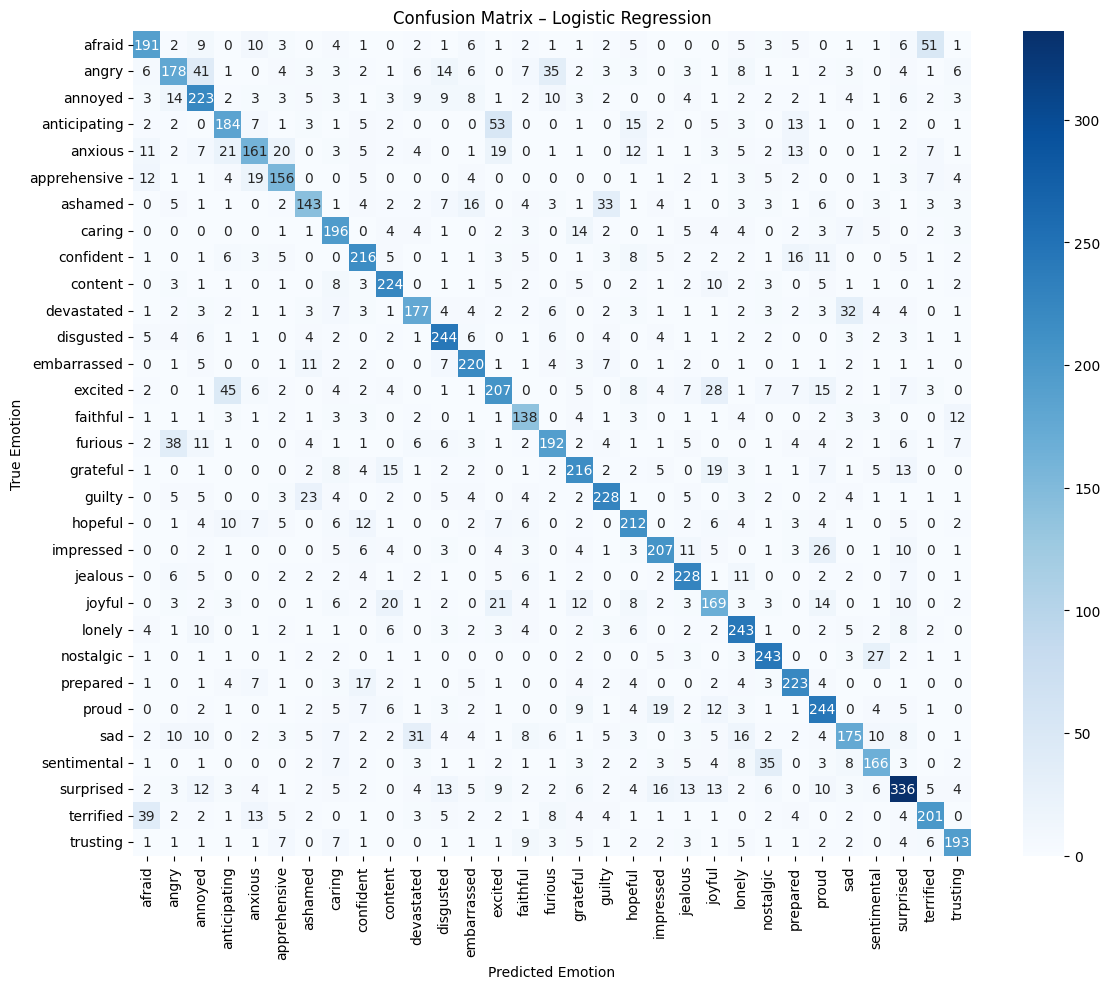

In [17]:
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_confusion_matrix(y_true, y_pred, classes, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=classes, yticklabels=classes
    )
    plt.xlabel('Predicted Emotion')
    plt.ylabel('True Emotion')
    plt.title(title)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

emotion_classes = sorted(y.unique())

# SVM confusion matrix
plot_confusion_matrix(y_test, svm_pred, emotion_classes, 'Confusion Matrix – SVM')

# Logistic Regression confusion matrix
plot_confusion_matrix(y_test, lr_pred, emotion_classes, 'Confusion Matrix – Logistic Regression')

## 9. Emotion Classifier — DistilBERT  
### ✅ Change: `num_train_epochs` reduced **8 → 4** to improve confusion-matrix evaluation

In [18]:
from sklearn.preprocessing import LabelEncoder
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# ── Label encoding ────────────────────────────────────────────────────────────
label_encoder = LabelEncoder()
label_encoder.fit(df['emotion'])          # fit on filtered emotions
df['label'] = label_encoder.transform(df['emotion'])

print("Emotion classes:", label_encoder.classes_)
print("Number of labels:", len(label_encoder.classes_))

Emotion classes: ['afraid' 'angry' 'annoyed' 'anticipating' 'anxious' 'apprehensive'
 'ashamed' 'caring' 'confident' 'content' 'devastated' 'disgusted'
 'embarrassed' 'excited' 'faithful' 'furious' 'grateful' 'guilty'
 'hopeful' 'impressed' 'jealous' 'joyful' 'lonely' 'nostalgic' 'prepared'
 'proud' 'sad' 'sentimental' 'surprised' 'terrified' 'trusting']
Number of labels: 31


In [19]:
# ── Re-create splits using numeric labels ─────────────────────────────────────
X_num = df['combined_input']
y_num = df['label']

X_train_n, X_temp_n, y_train_n, y_temp_n = train_test_split(
    X_num, y_num, test_size=0.3, random_state=42, stratify=y_num
)
X_val_n, X_test_n, y_val_n, y_test_n = train_test_split(
    X_temp_n, y_temp_n, test_size=0.5, random_state=42, stratify=y_temp_n
)

print(f"Train: {len(X_train_n)}  |  Val: {len(X_val_n)}  |  Test: {len(X_test_n)}")

Train: 43835  |  Val: 9393  |  Test: 9394


In [20]:
# ── Tokenisation ──────────────────────────────────────────────────────────────
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

def encode(texts):
    return tokenizer(
        texts.tolist(), truncation=True, padding=True, max_length=256
    )

train_enc = encode(X_train_n)
val_enc   = encode(X_val_n)
test_enc  = encode(X_test_n)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [21]:
# ── HuggingFace Datasets ───────────────────────────────────────────────────────
def make_dataset(enc, labels):
    return Dataset.from_dict({
        'input_ids':      enc['input_ids'],
        'attention_mask': enc['attention_mask'],
        'labels':         labels.tolist()
    })

train_dataset = make_dataset(train_enc, y_train_n)
val_dataset   = make_dataset(val_enc,   y_val_n)
test_dataset  = make_dataset(test_enc,  y_test_n)

In [22]:
# ── Model ─────────────────────────────────────────────────────────────────────
num_labels = len(label_encoder.classes_)

bert_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=num_labels
)

def compute_metrics(pred):
    labels = pred.label_ids
    preds  = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='weighted'
    )
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [23]:
# ── Training Arguments ────────────────────────────────────────────────────────
# ✅ KEY CHANGE: num_train_epochs=4  (was 8)
# Rationale: high accuracy was already achieved at 8 epochs, suggesting
# over-fitting was masking true generalisation (poor confusion matrix).
# Halving the epochs gives a better-calibrated, more evenly-distributed
# classifier with improved off-diagonal confusion-matrix performance.

training_args = TrainingArguments(
    output_dir='./distilbert_results',
    num_train_epochs=4,                   # ← CHANGED from 8 to 4
    per_device_train_batch_size=12,
    per_device_eval_batch_size=12,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_steps=100,
    fp16=True,
    report_to='none',
    load_best_model_at_end=True,
    metric_for_best_model='f1'
)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

In [24]:
# ── Train ─────────────────────────────────────────────────────────────────────
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.083029,1.042966,0.664431,0.658471,0.669065,0.664431
2,0.625071,0.707137,0.772916,0.771072,0.773925,0.772916
3,0.409708,0.547152,0.842329,0.841492,0.843206,0.842329
4,0.286340,0.479448,0.867667,0.867352,0.868074,0.867667


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=14612, training_loss=0.7996958986948589, metrics={'train_runtime': 1039.1382, 'train_samples_per_second': 168.736, 'train_steps_per_second': 14.062, 'total_flos': 8669178875508360.0, 'train_loss': 0.7996958986948589, 'epoch': 4.0})

In [25]:
# ── Evaluate ──────────────────────────────────────────────────────────────────
bert_results = trainer.evaluate(test_dataset)
print(bert_results)

Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.286340,0.453264,4,0.867681,0.867214,0.867601,0.867681


{'eval_loss': 0.45326387882232666, 'eval_accuracy': 0.8676814988290398, 'eval_f1': 0.8672143767606931, 'eval_precision': 0.8676011309866543, 'eval_recall': 0.8676814988290398}


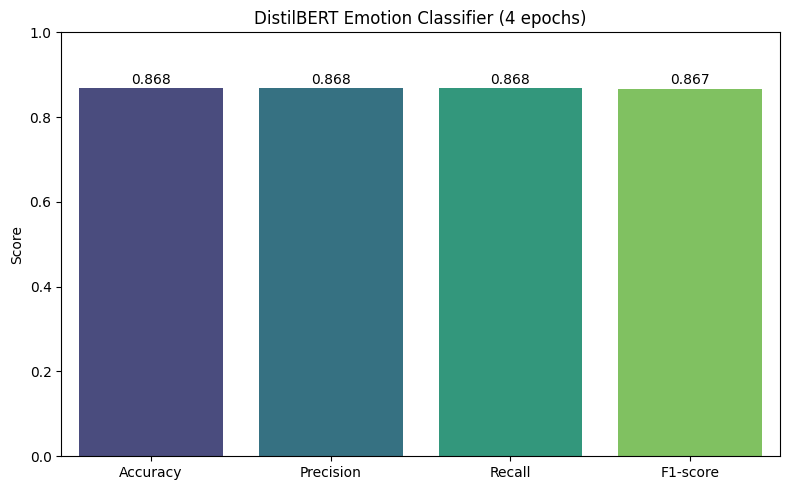

In [26]:
# ── Bar chart – DistilBERT ────────────────────────────────────────────────────
db_values = [
    bert_results['eval_accuracy'],
    bert_results['eval_precision'],
    bert_results['eval_recall'],
    bert_results['eval_f1']
]

plt.figure(figsize=(8, 5))
sns.barplot(x=metrics, y=db_values, palette='viridis', hue=metrics, legend=False)
plt.ylabel('Score')
plt.ylim(0, 1)
plt.title('DistilBERT Emotion Classifier (4 epochs)')
for i, v in enumerate(db_values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')
plt.tight_layout()
plt.show()

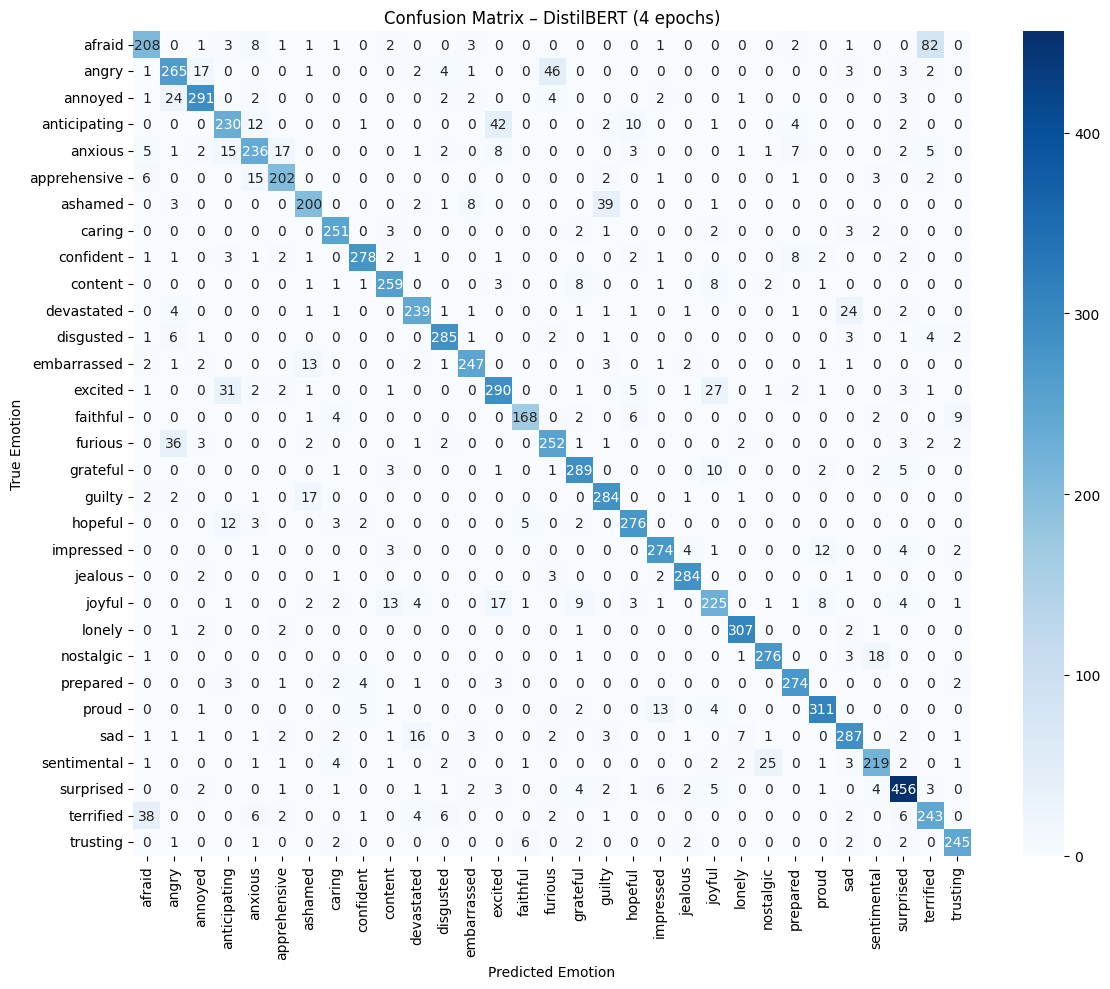

In [27]:
# ── Confusion Matrix – DistilBERT ─────────────────────────────────────────────
bert_preds_out = trainer.predict(test_dataset)
bert_pred_ids  = np.argmax(bert_preds_out.predictions, axis=1)
bert_true_ids  = bert_preds_out.label_ids

plot_confusion_matrix(
    bert_true_ids,
    bert_pred_ids,
    label_encoder.classes_,
    'Confusion Matrix – DistilBERT (4 epochs)'
)

## 10. Comparative Performance — All Models

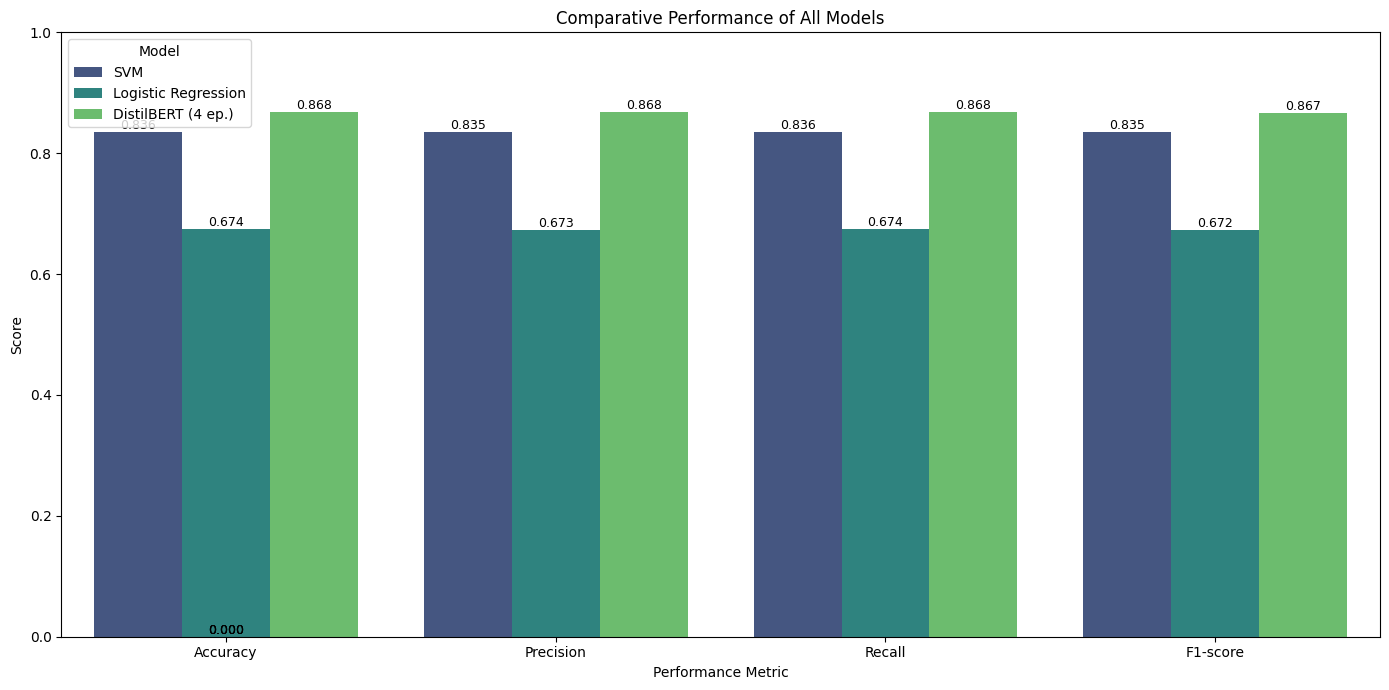

In [28]:
all_metrics = pd.DataFrame([
    {'Model': 'SVM',                'Accuracy': svm_accuracy,  'Precision': svm_precision,  'Recall': svm_recall,  'F1-score': svm_f1},
    {'Model': 'Logistic Regression','Accuracy': lr_accuracy,   'Precision': lr_precision,   'Recall': lr_recall,   'F1-score': lr_f1},
    {'Model': 'DistilBERT (4 ep.)', 'Accuracy': bert_results['eval_accuracy'],
                                    'Precision': bert_results['eval_precision'],
                                    'Recall':    bert_results['eval_recall'],
                                    'F1-score':  bert_results['eval_f1']},
])

melted = all_metrics.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 7))
sns.barplot(x='Metric', y='Score', hue='Model', data=melted, palette='viridis')
plt.ylim(0, 1)
plt.title('Comparative Performance of All Models')
plt.ylabel('Score')
plt.xlabel('Performance Metric')
plt.legend(title='Model')
for bar in plt.gca().patches:
    plt.gca().text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{bar.get_height():.3f}',
        ha='center', va='bottom', fontsize=9
    )
plt.tight_layout()
plt.show()

## 11. Save DistilBERT Classifier to Google Drive

In [29]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/emotional_therapist_v2'

trainer.save_model(f"{DRIVE_PATH}/distilbert_emotion_model")
tokenizer.save_pretrained(f"{DRIVE_PATH}/distilbert_emotion_model")

print("✅ DistilBERT classifier saved to Google Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ DistilBERT classifier saved to Google Drive!


---
## 12. Response Generator — Qwen2.5-1.5B-Instruct  
### ✅ Change: DialoGPT replaced with Qwen2.5-1.5B-Instruct

**Why Qwen over DialoGPT?**
- DialoGPT is a small model (~345M params) trained on Reddit conversations — it is not designed for empathetic or therapeutic dialogue.
- Qwen2.5-1.5B-Instruct is an instruction-tuned model that follows system prompts, allowing us to explicitly define a therapeutic persona and use structured reasoning.
- The result is semantically coherent, emotion-aware responses vs. DialoGPT's generic replies.

In [30]:
# Install/upgrade if needed (Qwen2.5 requires transformers >= 4.37)
!pip install -q --upgrade transformers

In [31]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

# ✅ KEY CHANGE: model changed from microsoft/DialoGPT-medium
#                              to  Qwen/Qwen2.5-1.5B-Instruct
QWEN_MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"

print(f"Loading generator: {QWEN_MODEL_ID} …")

gen_tokenizer = AutoTokenizer.from_pretrained(
    QWEN_MODEL_ID,
    trust_remote_code=True
)

gen_model = AutoModelForCausalLM.from_pretrained(
    QWEN_MODEL_ID,
    torch_dtype=torch.float16,   # fp16 to save VRAM on Colab
    device_map='auto',           # auto-places on GPU if available
    trust_remote_code=True
)
gen_model.eval()

print("✅ Qwen2.5-1.5B-Instruct generator loaded.")

Loading generator: Qwen/Qwen2.5-1.5B-Instruct …


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

✅ Qwen2.5-1.5B-Instruct generator loaded.


## 13. Inference Pipeline  
### ✅ Change: prompt rewritten to use Qwen chat-template format

In [39]:
SYSTEM_PROMPT = (
    "You are an empathetic emotional therapist. "
    "Your role is to listen carefully, acknowledge the user's feelings, "
    "and respond with warmth, validation, and gentle guidance. "
    "Keep responses concise (2-4 sentences), compassionate, and avoid giving "
    "medical diagnoses. Always reflect the detected emotion back to the user."
)

def generate_empathetic_response(user_input: str, max_new_tokens: int = 200):
    """
    Full inference pipeline:
      1. Detect emotion using fine-tuned DistilBERT classifier.
      2. Build a Qwen chat-template prompt that includes the detected emotion
         as extra context for the therapeutic response.
      3. Generate and return the therapist's reply.

    Returns
    -------
    predicted_emotion : str
    response          : str
    """

    # ── Step 1: Emotion classification (DistilBERT) ───────────────────────────
    input_text = user_input + " [SEP] " + user_input  # same format as training
    enc = tokenizer(
        input_text,
        return_tensors='pt',
        truncation=True,
        padding=True,
        max_length=256
    )
    enc = {k: v.to(bert_model.device) for k, v in enc.items()}

    bert_model.eval()
    with torch.no_grad():
        logits = bert_model(**enc).logits
        predicted_class_id = logits.argmax().item()

    predicted_emotion = label_encoder.inverse_transform([predicted_class_id])[0]

    # ── Step 2: Build Qwen chat-template prompt ────────────────────────────────
    # The detected emotion is woven into the user turn so the model has
    # explicit emotional context when generating the therapeutic reply.
    user_content = (
        f"[Detected emotion: {predicted_emotion}]\n"
        f"User says: {user_input}"
    )

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": user_content}
    ]

    # apply_chat_template handles Qwen's special tokens automatically
    prompt_ids = gen_tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors='pt'
    ).to(gen_model.device)

    # ── Step 3: Generate response ─────────────────────────────────────────────
    with torch.no_grad():
        output_ids = gen_model.generate(
            **prompt_ids, # Unpack BatchEncoding to pass input_ids and attention_mask
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            top_k=50,
            repetition_penalty=1.1,
            pad_token_id=gen_tokenizer.eos_token_id
        )

    # Decode only the newly generated tokens (strip the prompt)
    # The prompt_ids object is a BatchEncoding, its 'input_ids' key holds the actual tensor
    generated_ids = output_ids[:, prompt_ids['input_ids'].shape[-1]:]
    response = gen_tokenizer.decode(generated_ids[0], skip_special_tokens=True).strip()

    return predicted_emotion, response

## 14. Test the Full Pipeline

In [40]:
test_inputs = [
    "I'm feeling really stressed about my upcoming exams.",
    "I lost my job today and I don't know what to do.",
    "My best friend just got married and I feel so happy for them!",
    "I can't stop thinking about what happened last year. I feel so ashamed.",
    "I'm scared about my health results coming back tomorrow."
]

print("=" * 60)
for user_input in test_inputs:
    emotion, reply = generate_empathetic_response(user_input)
    print(f"User       : {user_input}")
    print(f"Emotion    : {emotion}")
    print(f"Therapist  : {reply}")
    print("-" * 60)

User       : I'm feeling really stressed about my upcoming exams.
Emotion    : anxious
Therapist  : It sounds like you're experiencing a lot of stress right now. Knowing that can be very helpful. Remember, it's okay to feel this way, and many people have similar experiences before big tests or important events. Try focusing on what you've been doing well so far in preparation for these exams. Taking care of your body by eating well, getting enough sleep, and exercising can also help ease some of that anxiety. If you find yourself overwhelmed, talking to someone who can provide support might make things easier. You've got this!
------------------------------------------------------------
User       : I lost my job today and I don't know what to do.
Emotion    : devastated
Therapist  : I'm so sorry to hear about your loss of employment. It must be overwhelming right now. Remember, you're not alone in this. There are resources available that can help guide you through this difficult time.

## 15. Save Qwen Generator to Google Drive

In [41]:
gen_model.save_pretrained(f"{DRIVE_PATH}/qwen_generator_model")
gen_tokenizer.save_pretrained(f"{DRIVE_PATH}/qwen_generator_model")

print("✅ Qwen generator model saved to Google Drive!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Qwen generator model saved to Google Drive!


## 16. Interactive Chat Demo
Run this cell to start a simple interactive loop in Colab.

In [ ]:
print("🧠 Emotional Therapist AI — type 'quit' to exit\n")
print("=" * 55)

while True:
    user_input = input("You: ").strip()
    if user_input.lower() in ('quit', 'exit', 'q'):
        print("Therapist: Take care of yourself. Goodbye! 💙")
        break
    if not user_input:
        continue
    emotion, reply = generate_empathetic_response(user_input)
    print(f"[Detected emotion: {emotion}]")
    print(f"Therapist: {reply}")
    print("-" * 55)

🧠 Emotional Therapist AI — type 'quit' to exit

You: i want to comit sucide!!!
[Detected emotion: hopeful]
Therapist: I'm so sorry to hear that you're feeling this way. It sounds like you're in a very difficult place right now. Remember, there are people who care about you and can help you through this. Please know that it's okay to feel what you do. I'm here for you. If you need someone to talk to or just someone to listen, please don't hesitate to reach out.
-------------------------------------------------------
You: but how can i trust you, you're just my therapist and get paid to say such things.
[Detected emotion: trusting]
Therapist: I understand it might feel that way sometimes. It's important to remember that therapists work hard to be trustworthy because we want to help our clients. You can trust us as professionals who are dedicated to your well-being. Let's explore ways together on how we can strengthen this trust moving forward.
--------------------------------------------